# Olist E-Commerce Analysis
## Notebook 5 — Delivery Analysis
**Goal:** Understand delivery performance — average times, late deliveries, state differences, and impact on customer satisfaction.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA = 'C:/Users/loayi/OneDrive/Desktop/Workspace/olist-analysis/data/'

df = pd.read_csv(DATA + 'master.csv')
reviews = pd.read_csv(DATA + 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(DATA + 'olist_orders_dataset.csv')

df = pd.merge(df,reviews,how='left',on='order_id')
df = df.rename(columns={
    'order_purchase_timestamp_x': 'order_purchase_timestamp',
    'order_delivered_customer_date_x': 'order_delivered_customer_date',
    'order_estimated_delivery_date_x': 'order_estimated_delivery_date'
})
def change_dates(date,df):
    return pd.to_datetime(df[date])
date_cols = [col for col in df.columns if 'date' in col or 'timestamp' in col]

df[date_cols] = df[date_cols].apply(pd.to_datetime)


## 1. Average Delivery Time


In [105]:

delivery = df['order_delivered_customer_date'] - df['order_purchase_timestamp']
df['delivery_days'] = delivery.dt.days
print(df['delivery_days'].mean())

12.012036235022377


**Insight:**

## 2. Average Delivery Time by State


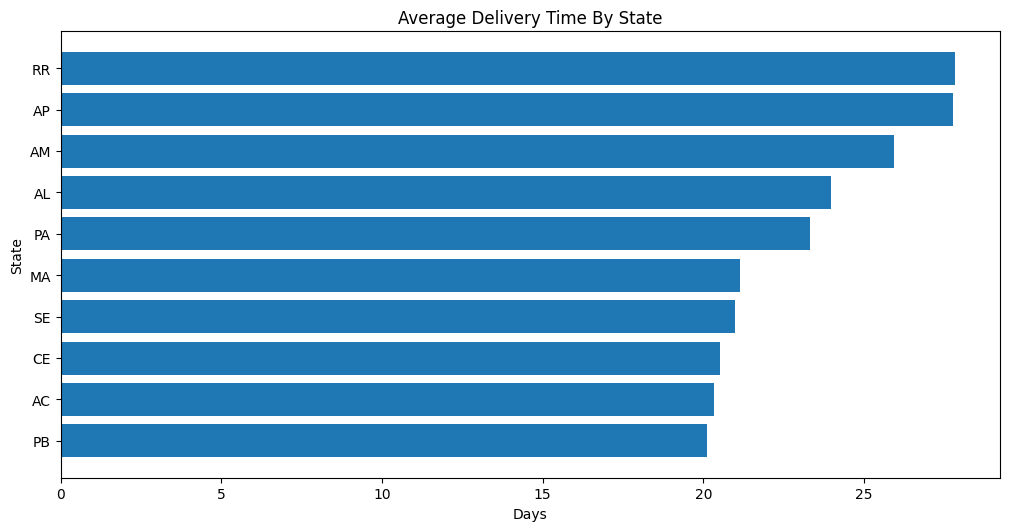

In [106]:
wht = df.groupby('customer_state')['delivery_days'].mean().sort_values().tail(10)
plt.figure(figsize= (10,5))
plt.barh(wht.index,wht.values)
plt.tight_layout()
plt.title("Average Delivery Time By State")
plt.xlabel('Days')
plt.ylabel('State')
plt.show()


**Insight:**

## 3. Late Deliveries


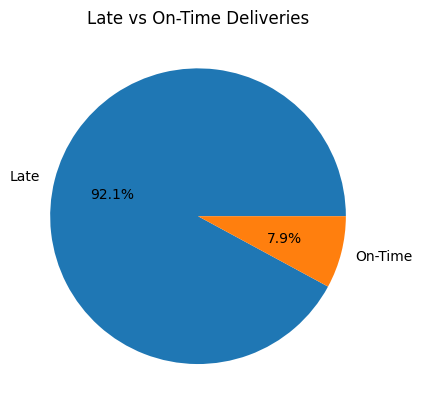

In [107]:
s = np.where(df['order_estimated_delivery_date'] <= df['order_delivered_customer_date'],'On-Time','Late')
counts = pd.Series(s).value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Late vs On-Time Deliveries')
plt.show()

**Insight:**

## 4. Delivery Time vs Review Score


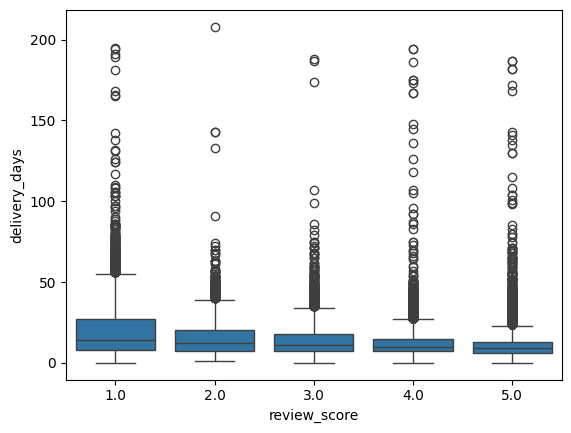

In [108]:
sns.boxplot(data=df, x='review_score', y='delivery_days')
plt.show()


**Insight:**

## 5. Review Score by Delivery Status


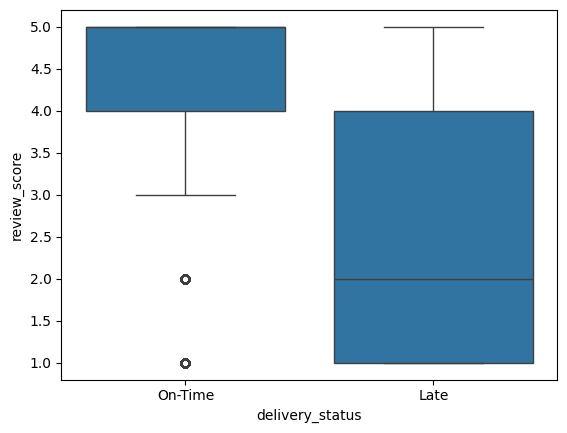

In [113]:
df['delivery_status'] = np.where(df['order_delivered_customer_date'] > df['order_estimated_delivery_date'], 'Late', 'On-Time')
sns.boxplot(data=df, x='delivery_status', y='review_score')
plt.show()


**Insight:**